In [4]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_finops_eda():
    print("\n[Bước 1] Khảo sát tổng quan cấu trúc các tệp tin dữ liệu:")
    csv_files = [
        'cost_explorer_daily.csv', 'cur_line_items.csv', 'ddb_metrics.csv',
        'ec2_metrics.csv', 'rds_metrics.csv', 'sagemaker_metrics.csv',
        'other_services_metrics.csv'
    ]
    
    for file in csv_files:
        if os.path.exists(file):
            df_temp = pd.read_csv(file, nrows=2)
            print(f" File: {file:<28} | Số cột: {len(df_temp.columns):<2} | Các cột chính: {list(df_temp.columns[:5])}...")
        else:
            print(f" Cảnh báo: Không tìm thấy file {file}")

    print("\n[Bước 2] Phân tích Chi phí tầng Vĩ mô (Cost Explorer Daily):")
    ce_df = pd.read_csv('cost_explorer_daily.csv')
    ce_df['date'] = pd.to_datetime(ce_df['date'])
    
    total_ce_cost = ce_df['unblended_cost'].sum()
    min_date = ce_df['date'].min().strftime('%Y-%m-%d')
    max_date = ce_df['date'].max().strftime('%Y-%m-%d')
    
    print(f" 🔹 Khoảng thời gian thu thập dữ liệu: Từ {min_date} đến {max_date}")
    print(f" 🔹 Tổng chi phí lũy kế ghi nhận (Unblended Cost): ${total_ce_cost:,.2f} USD")

    print("\n Top 5 dịch vụ tiêu dùng tài nguyên lớn nhất:")
    service_summary = ce_df.groupby('service_code')['unblended_cost'].sum().sort_values(ascending=False)
    for idx, (svc, cost) in enumerate(service_summary.head(5).items(), 1):
        pct = (cost / total_ce_cost) * 100
        print(f"   {idx}. {svc:<18}: ${cost:11,.2f} USD ({pct:.2f}%)")

    print("\n Phân phối chi phí theo các tài khoản (Linked Accounts):")
    account_summary = ce_df.groupby('linked_account_name')['unblended_cost'].sum().sort_values(ascending=False)
    for idx, (acc, cost) in enumerate(account_summary.items(), 1):
        pct = (cost / total_ce_cost) * 100
        print(f"   {idx}. Tài khoản: {acc:<15} : ${cost:11,.2f} USD ({pct:.2f}%)")

    print("\n[Bước 3] Phân tích Chi tiết cấp Tài nguyên & Chất lượng Tagging (CUR):")
    cur_df = pd.read_csv('cur_line_items.csv')
    
    total_cur_rows = len(cur_df)
    print(f" 🔹 Tổng số dòng bản ghi chi tiết tài nguyên (CUR Line Items): {total_cur_rows:,} dòng")

    untagged_rows = cur_df['resource_tags_user_team'].isna().sum()
    untagged_cost = cur_df[cur_df['resource_tags_user_team'].isna()]['line_item_unblended_cost'].sum()

    cur_df['resource_tags_user_team'] = cur_df['resource_tags_user_team'].fillna('Untagged / Missing')
    team_costs = cur_df.groupby('resource_tags_user_team')['line_item_unblended_cost'].sum().sort_values(ascending=False)
    
    print(f" 🔹 Kiểm toán Tagging: Phát hiện {untagged_rows:,} dòng thiếu tag 'team', tương ứng lãng phí vô chủ: ${untagged_cost:,.2f} USD")
    print("\n Bảng phân bổ hóa đơn theo Squad/Team quản lý:")
    for idx, (team, cost) in enumerate(team_costs.items(), 1):
        print(f"   {idx}. Squad: {team:<18} -> Chi phí: ${cost:11,.2f} USD")

    print("\n[Bước 4] Phân tích Hồ sơ Hiệu năng Vật lý & Đặc trưng nhãn (Metrics Layer):")
    metrics_files = {
        'EC2': 'ec2_metrics.csv',
        'RDS': 'rds_metrics.csv',
        'DynamoDB': 'ddb_metrics.csv',
        'SageMaker': 'sagemaker_metrics.csv'
    }
    
    for svc_name, filename in metrics_files.items():
        if os.path.exists(filename):
            m_df = pd.read_csv(filename)
            print(f"\n Phân tích hồ sơ nhãn dịch vụ {svc_name} ({filename}):")

            counts_str = "\n".join([f"     {str(index):<10} : {value:,} bản ghi" for index, value in m_df['label'].value_counts().items()])
            print(f"   - Phân phối nhãn dữ liệu thực tế:\n{counts_str}")

            if 'cpu_percent' in m_df.columns:
                cpu_by_label = m_df.groupby('label')['cpu_percent'].mean()
                print("   - Hiệu suất CPU sử dụng trung bình theo từng nhóm hành vi:")
                for lbl, val in cpu_by_label.items():
                    print(f"     + Nhóm [{lbl:<7}]: {val:.2f}% CPU")

    print("\n[Bước 5] Tạo dựng biểu đồ dòng thời gian chi phí để phát hiện đột biến:")
    daily_trend = ce_df.groupby('date')['unblended_cost'].sum().sort_index()

    plt.plot(daily_trend.index, daily_trend.values, label='Chi phí hàng ngày (USD)', color='#1f77b4', linewidth=2)
    
    peak_date = daily_trend.idxmax()
    peak_value = daily_trend.max()
    plt.scatter(peak_date, peak_value, color='red', s=80, zorder=5, label=f"Đỉnh đột biến ({peak_date.strftime('%m-%d')})")
    
    plt.title('AWS Daily Cost Trend & Spike Analysis (March - May 2026)', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Dòng thời gian (Ngày)', fontsize=10)
    plt.ylabel('Hóa đơn phát sinh (USD / Ngày)', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=30)
    plt.legend(loc='upper left')
    plt.tight_layout()

    output_img = 'aws_daily_cost_trend.png'
    plt.savefig(output_img, dpi=150)
    plt.close()
    print(f" Biểu đồ xu hướng biến động hóa đơn đã được xuất thành công: {output_img}")

    summary_csv = 'finops_macro_service_summary.csv'
    service_summary.reset_index().to_csv(summary_csv, index=False)
    print(f" Báo cáo tóm tắt phân phối chi phí theo dịch vụ đã được ghi lại: {summary_csv}")

if __name__ == '__main__':
    run_finops_eda()


[Bước 1] Khảo sát tổng quan cấu trúc các tệp tin dữ liệu:
 File: cost_explorer_daily.csv      | Số cột: 8  | Các cột chính: ['date', 'linked_account_id', 'linked_account_name', 'service', 'service_code']...
 File: cur_line_items.csv           | Số cột: 23 | Các cột chính: ['bill_billing_period_start_date', 'bill_payer_account_id', 'line_item_usage_account_id', 'line_item_usage_account_name', 'line_item_line_item_type']...
 File: ddb_metrics.csv              | Số cột: 32 | Các cột chính: ['resource_id', 'timestamp', 'cpu_percent', 'memory_mib', 'network_in_bytes']...
 File: ec2_metrics.csv              | Số cột: 33 | Các cột chính: ['resource_id', 'timestamp', 'cpu_percent', 'memory_mib', 'network_in_bytes']...
 File: rds_metrics.csv              | Số cột: 33 | Các cột chính: ['resource_id', 'timestamp', 'cpu_percent', 'memory_mib', 'network_in_bytes']...
 File: sagemaker_metrics.csv        | Số cột: 33 | Các cột chính: ['resource_id', 'timestamp', 'cpu_percent', 'memory_mib', 'network

====== GIAI ĐOẠN 1: PHÂN TÍCH ĐỘC LẬP TỪNG FILE & FEATURE ======
[Processing] Phân tích phân phối và độ lệch tính năng của Cost Explorer...


C:\Users\asus laptop\AppData\Local\Temp\ipykernel_19264\406054223.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ce_df, x='linked_account_name', y='unblended_cost', ax=axes[1], palette='Set2')


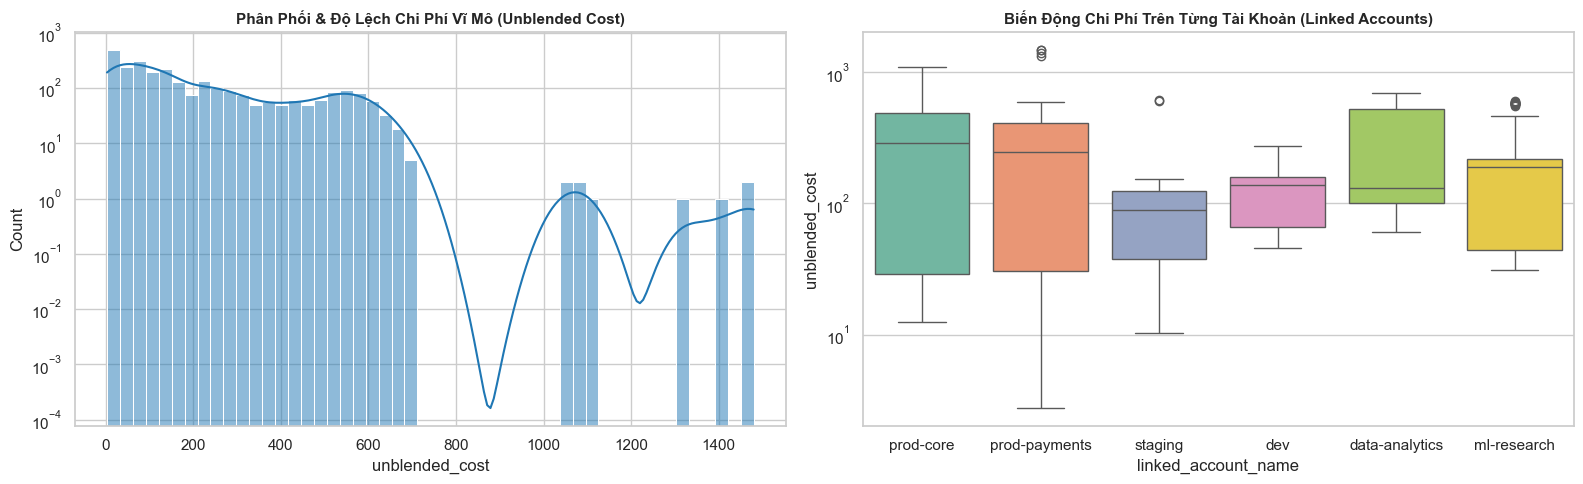

[Processing] Phân tích tình trạng cấu trúc Tagging của file CUR...


C:\Users\asus laptop\AppData\Local\Temp\ipykernel_19264\406054223.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_counts.values, y=team_counts.index, ax=axes[0], palette='viridis')


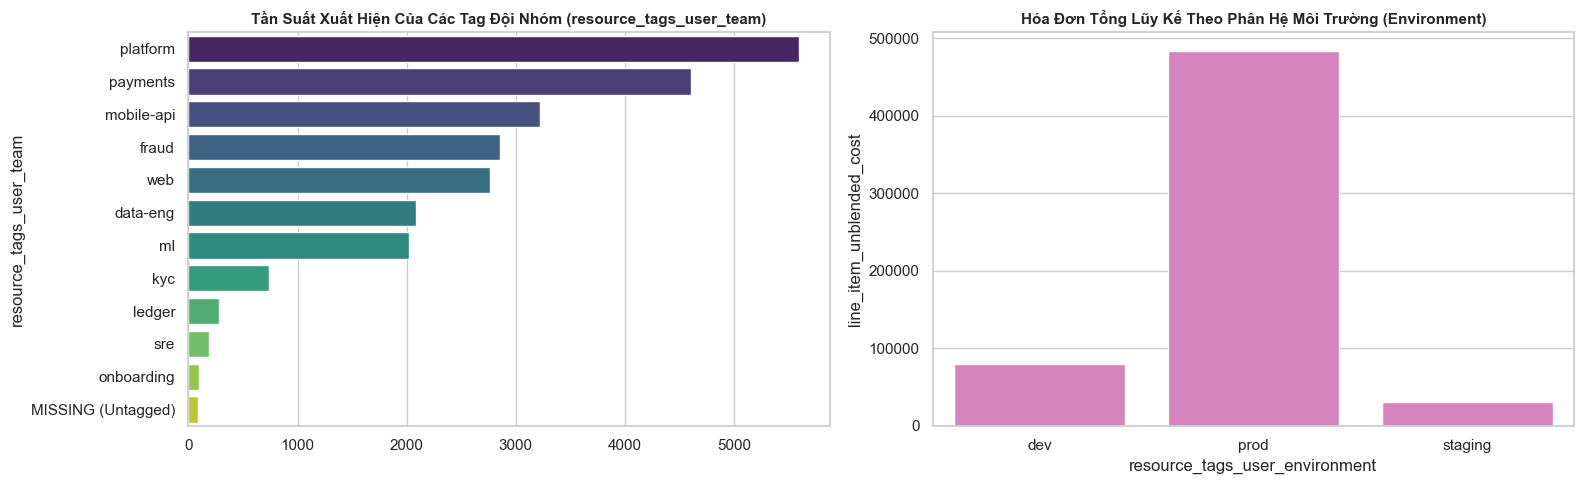

[Processing] Phân tích tính năng hiệu năng vật lý file ec2_metrics.csv...


C:\Users\asus laptop\AppData\Local\Temp\ipykernel_19264\406054223.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=m_df, x='label', y='cpu_percent', ax=axes[0], inner="quartile", palette='muted')


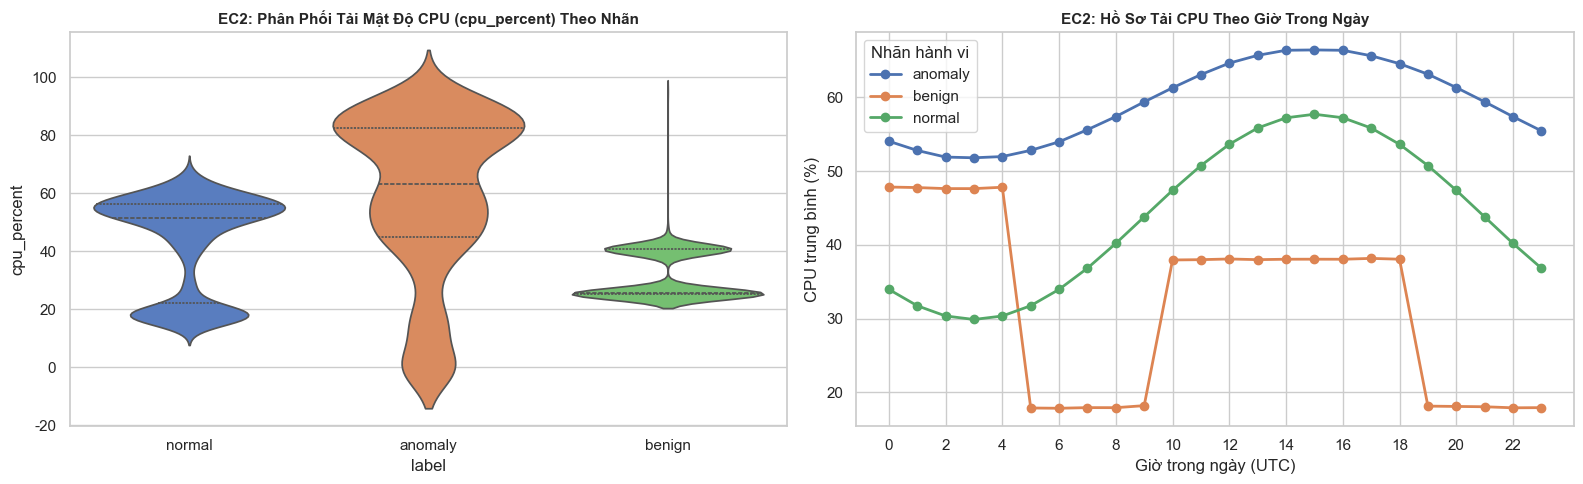

[Processing] Phân tích tính năng hiệu năng vật lý file sagemaker_metrics.csv...


C:\Users\asus laptop\AppData\Local\Temp\ipykernel_19264\406054223.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=m_df, x='label', y='cpu_percent', ax=axes[0], inner="quartile", palette='muted')


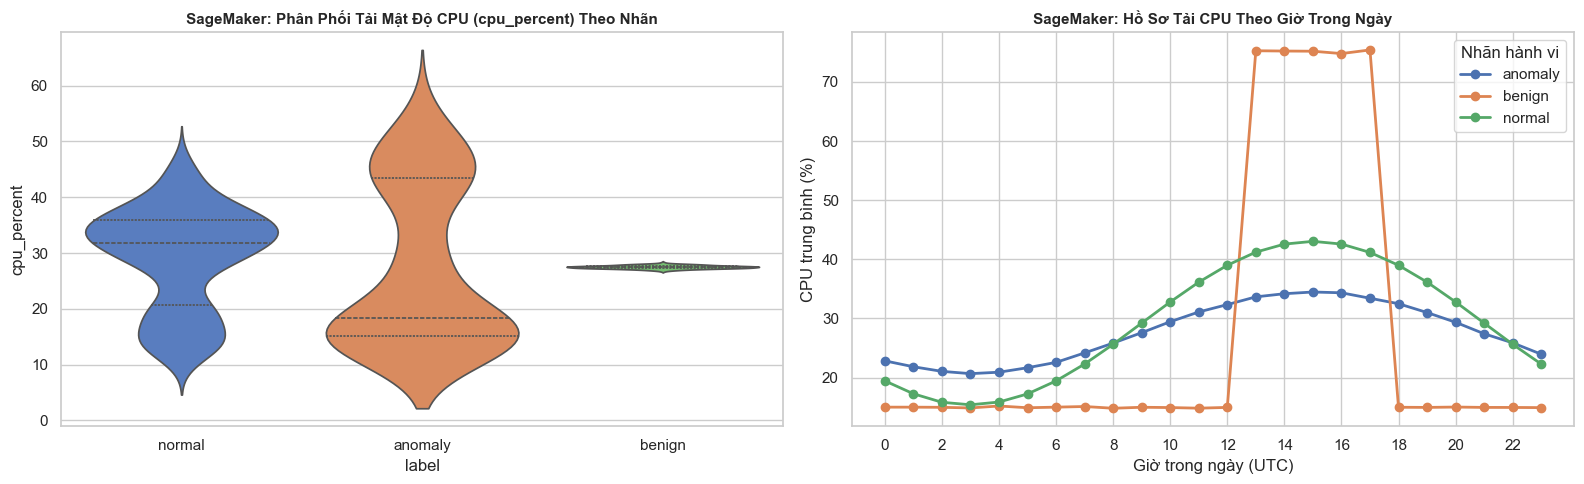


====== GIAI ĐOẠN 2: BIỂU ĐỒ PHÂN TÍCH CHUNG PHỐI HỢP VÀ CHU KỲ NÂNG CAO ======


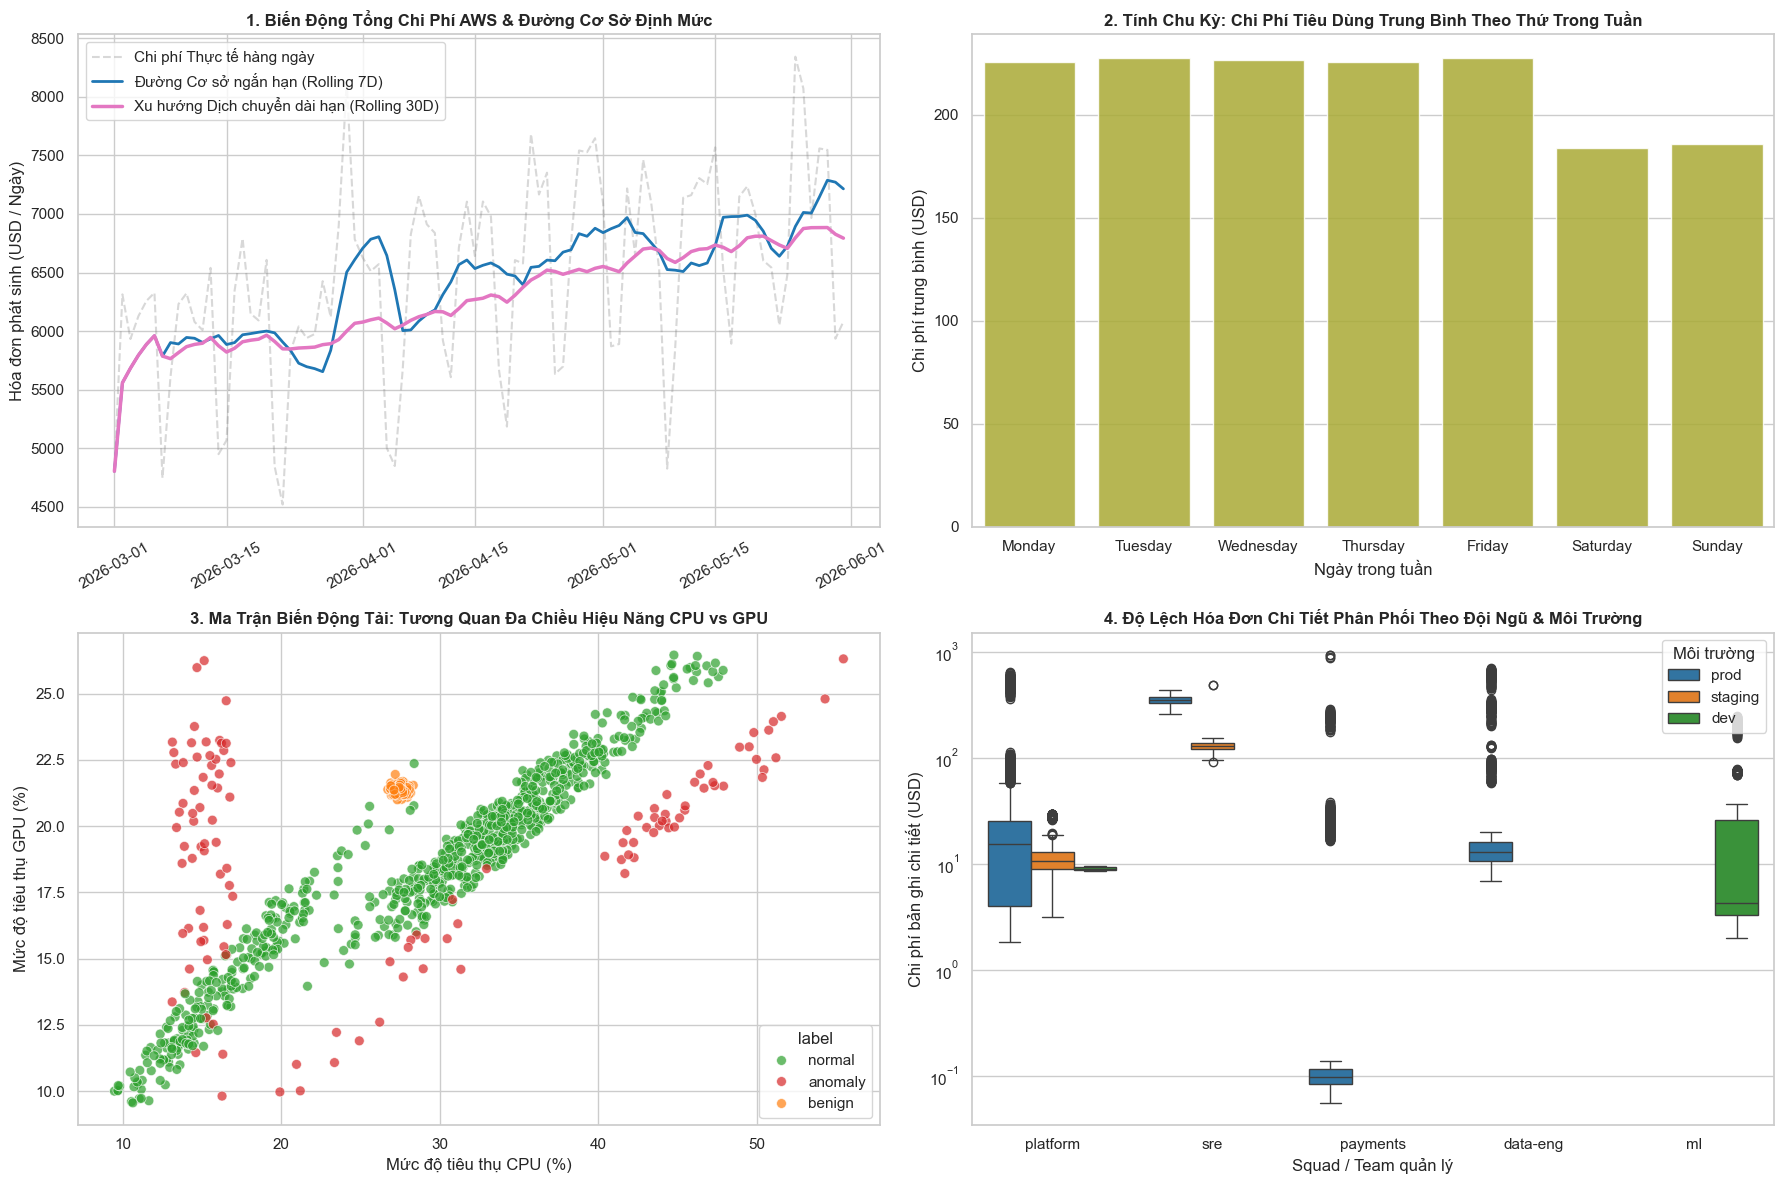

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

print("====== GIAI ĐOẠN 1: PHÂN TÍCH ĐỘC LẬP TỪNG FILE & FEATURE ======")

if os.path.exists('cost_explorer_daily.csv'):
    print("[Processing] Phân tích phân phối và độ lệch tính năng của Cost Explorer...")
    ce_df = pd.read_csv('cost_explorer_daily.csv')
    ce_df['date'] = pd.to_datetime(ce_df['date'])
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.histplot(data=ce_df, x='unblended_cost', bins=50, kde=True, ax=axes[0], color='#1f77b4')
    axes[0].set_title('Phân Phối & Độ Lệch Chi Phí Vĩ Mô (Unblended Cost)', fontsize=11, fontweight='bold')
    axes[0].set_yscale('log')
    sns.boxplot(data=ce_df, x='linked_account_name', y='unblended_cost', ax=axes[1], palette='Set2')
    axes[1].set_title('Biến Động Chi Phí Trên Từng Tài Khoản (Linked Accounts)', fontsize=11, fontweight='bold')
    axes[1].set_yscale('log')
    plt.tight_layout()
    plt.show()

if os.path.exists('cur_line_items.csv'):
    print("[Processing] Phân tích tình trạng cấu trúc Tagging của file CUR...")
    cur_df = pd.read_csv('cur_line_items.csv')
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    cur_df['resource_tags_user_team'] = cur_df['resource_tags_user_team'].fillna('MISSING (Untagged)')
    team_counts = cur_df['resource_tags_user_team'].value_counts()
    sns.barplot(x=team_counts.values, y=team_counts.index, ax=axes[0], palette='viridis')
    axes[0].set_title('Tần Suất Xuất Hiện Của Các Tag Đội Nhóm (resource_tags_user_team)', fontsize=11, fontweight='bold')

    env_costs = cur_df.groupby('resource_tags_user_environment')['line_item_unblended_cost'].sum().reset_index()
    sns.barplot(data=env_costs, x='resource_tags_user_environment', y='line_item_unblended_cost', ax=axes[1], color='#e377c2')
    axes[1].set_title('Hóa Đơn Tổng Lũy Kế Theo Phân Hệ Môi Trường (Environment)', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

metrics_to_plot = {'EC2': 'ec2_metrics.csv', 'SageMaker': 'sagemaker_metrics.csv'}
for svc_name, filename in metrics_to_plot.items():
    if os.path.exists(filename):
        print(f"[Processing] Phân tích tính năng hiệu năng vật lý file {filename}...")
        m_df = pd.read_csv(filename)
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        sns.violinplot(data=m_df, x='label', y='cpu_percent', ax=axes[0], inner="quartile", palette='muted')
        axes[0].set_title(f'{svc_name}: Phân Phối Tải Mật Độ CPU (cpu_percent) Theo Nhãn', fontsize=11, fontweight='bold')

        cpu_hourly_cols = [f'cpu_h{i}' for i in range(24)]
        if all(col in m_df.columns for col in cpu_hourly_cols):
            hourly_profile = m_df.groupby('label')[cpu_hourly_cols].mean().T
            hourly_profile.index = range(24)
            axes[1].plot(hourly_profile.index, hourly_profile.values, marker='o', linewidth=2)
            axes[1].set_xticks(range(0, 24, 2))
            axes[1].set_xlabel('Giờ trong ngày (UTC)')
            axes[1].set_ylabel('CPU trung bình (%)')
            axes[1].legend(hourly_profile.columns, title='Nhãn hành vi')
            axes[1].set_title(f'{svc_name}: Hồ Sơ Tải CPU Theo Giờ Trong Ngày', fontsize=11, fontweight='bold')
            
        plt.tight_layout()
        plt.show()

print("\n====== GIAI ĐOẠN 2: BIỂU ĐỒ PHÂN TÍCH CHUNG PHỐI HỢP VÀ CHU KỲ NÂNG CAO ======")

if os.path.exists('cost_explorer_daily.csv') and os.path.exists('sagemaker_metrics.csv'):
    ce_df = pd.read_csv('cost_explorer_daily.csv')
    ce_df['date'] = pd.to_datetime(ce_df['date'])
    sm_df = pd.read_csv('sagemaker_metrics.csv')
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    daily_cost = ce_df.groupby('date')['unblended_cost'].sum().sort_index()
    rolling_7d = daily_cost.rolling(window=7, min_periods=1).mean()
    rolling_30d = daily_cost.rolling(window=30, min_periods=1).mean()
    
    axes[0, 0].plot(daily_cost.index, daily_cost.values, label='Chi phí Thực tế hàng ngày', color='#7f7f7f', alpha=0.3, linestyle='--')
    axes[0, 0].plot(rolling_7d.index, rolling_7d.values, label='Đường Cơ sở ngắn hạn (Rolling 7D)', color='#1f77b4', linewidth=2)
    axes[0, 0].plot(rolling_30d.index, rolling_30d.values, label='Xu hướng Dịch chuyển dài hạn (Rolling 30D)', color='#e377c2', linewidth=2.5)
    axes[0, 0].set_title('1. Biến Động Tổng Chi Phí AWS & Đường Cơ Sở Định Mức', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Hóa đơn phát sinh (USD / Ngày)')
    axes[0, 0].legend(loc='upper left')
    axes[0, 0].tick_params(axis='x', rotation=30)
    
    ce_df['day_of_week'] = ce_df['date'].dt.day_name()
    ce_df['day_num'] = ce_df['date'].dt.dayofweek
    weekly_pattern = ce_df.groupby(['day_num', 'day_of_week'])['unblended_cost'].mean().reset_index()
    
    sns.barplot(data=weekly_pattern, x='day_of_week', y='unblended_cost', ax=axes[0, 1], color='#bcbd22', alpha=0.85)
    axes[0, 1].set_title('2. Tính Chu Kỳ: Chi Phí Tiêu Dùng Trung Bình Theo Thứ Trong Tuần', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Ngày trong tuần')
    axes[0, 1].set_ylabel('Chi phí trung bình (USD)')

    sns.scatterplot(
        data=sm_df, x='cpu_percent', y='gpu_utilization', hue='label', ax=axes[1, 0],
        palette={'normal': '#2ca02c', 'anomaly': '#d62728', 'benign': '#ff7f0e'}, alpha=0.7, s=50
    )
    axes[1, 0].set_title('3. Ma Trận Biến Động Tải: Tương Quan Đa Chiều Hiệu Năng CPU vs GPU', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Mức độ tiêu thụ CPU (%)')
    axes[1, 0].set_ylabel('Mức độ tiêu thụ GPU (%)')

    if os.path.exists('cur_line_items.csv'):
        cur_df = pd.read_csv('cur_line_items.csv')
        cur_df['resource_tags_user_team'] = cur_df['resource_tags_user_team'].fillna('Missing')
        top_teams = cur_df.groupby('resource_tags_user_team')['line_item_unblended_cost'].sum().nlargest(5).index
        filtered_cur = cur_df[cur_df['resource_tags_user_team'].isin(top_teams)]
        
        sns.boxplot(data=filtered_cur, x='resource_tags_user_team', y='line_item_unblended_cost', 
                    hue='resource_tags_user_environment', ax=axes[1, 1], palette='tab10')
        axes[1, 1].set_title('4. Độ Lệch Hóa Đơn Chi Tiết Phân Phối Theo Đội Ngũ & Môi Trường', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Chi phí bản ghi chi tiết (USD)')
        axes[1, 1].set_yscale('log')
        axes[1, 1].set_xlabel('Squad / Team quản lý')
        axes[1, 1].legend(title='Môi trường', loc='upper right')

    plt.tight_layout()
    plt.show()